<a href="https://colab.research.google.com/github/paolapeiz/Practicas/blob/main/Practica2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install tensorflow tensorflow-datasets

In [2]:
import tensorflow as tf
import tensorflow_datasets as tfds
import numpy as np
import matplotlib.pyplot as plt

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

IMG_SIZE = 160
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

# Cargar Oxford-IIIT Pet
(ds_train_raw, ds_test_raw), ds_info = tfds.load(
    "oxford_iiit_pet",
    split=["train[:80%]", "train[80%:]"],
    with_info=True,
    as_supervised=True
)

label_names = ds_info.features["label"].names
num_classes = ds_info.features["label"].num_classes
print("Número de clases:", num_classes)
print("Primeras clases:", label_names[:10])

Número de clases: 37
Primeras clases: ['Abyssinian', 'american_bulldog', 'american_pit_bull_terrier', 'basset_hound', 'beagle', 'Bengal', 'Birman', 'Bombay', 'boxer', 'British_Shorthair']


In [3]:
RPG_ALIASES = {
    "abyssinian": "Felino del desierto",
    "american_bulldog": "Guardián pesado",
    "bengal": "Cazador sigiloso",
    "boxer": "Luchador de arena",
    "chihuahua": "Explorador pequeño",
    "egyptian_mau": "Gato místico",
    "great_pyrenees": "Tanque sagrado",
    "maine_coon": "Bestia nevada",
    "pomeranian": "Familiar mágico",
    "saint_bernard": "Guardián alpino",
    "samoyed": "Lobo de nieve",
    "siamese": "Gato arcano"
}

def rpg_name(label_name):
    return RPG_ALIASES.get(label_name, f"Criatura {label_name}")

print("Ejemplos de reinterpretación RPG:")
for name in label_names[:12]:
    print(f"{name:20} → {rpg_name(name)}")

Ejemplos de reinterpretación RPG:
Abyssinian           → Criatura Abyssinian
american_bulldog     → Guardián pesado
american_pit_bull_terrier → Criatura american_pit_bull_terrier
basset_hound         → Criatura basset_hound
beagle               → Criatura beagle
Bengal               → Criatura Bengal
Birman               → Criatura Birman
Bombay               → Criatura Bombay
boxer                → Luchador de arena
British_Shorthair    → Criatura British_Shorthair
chihuahua            → Explorador pequeño
Egyptian_Mau         → Criatura Egyptian_Mau


In [4]:
preprocess_input = tf.keras.applications.mobilenet_v2.preprocess_input

def preprocess(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = preprocess_input(tf.cast(image, tf.float32))
    return image, label

train_ds = (
    ds_train_raw
    .shuffle(2000, seed=SEED)
    .map(preprocess, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

test_ds = (
    ds_test_raw
    .map(preprocess, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

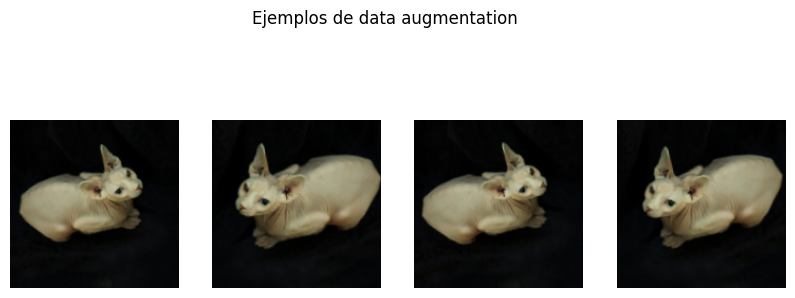

In [5]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal", name="flip"),   # Volteo horizontal (simula distintas orientaciones)
    tf.keras.layers.RandomRotation(0.05, name="rotate"),      # Pequeñas rotaciones (criaturas pueden estar ligeramente giradas)
    tf.keras.layers.RandomZoom(0.1, name="zoom"),             # Zoom aleatorio (ayuda a centrar la atención)
], name="data_augmentation")

# Visualización rápida de las augmentaciones
sample_image, sample_label = next(iter(ds_train_raw.take(1)))
plt.figure(figsize=(10,4))
for i in range(4):
    aug = data_augmentation(tf.expand_dims(tf.image.resize(sample_image, (IMG_SIZE, IMG_SIZE)), 0), training=True)
    plt.subplot(1,4,i+1)
    plt.imshow(tf.cast(aug[0], tf.uint8))
    plt.axis("off")
plt.suptitle("Ejemplos de data augmentation")
plt.show()

In [6]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights="imagenet"
)
base_model.trainable = False  # Congelamos la base

inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = data_augmentation(inputs)
x = base_model(x, training=False)   # base en modo inferencia
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.2)(x)  # Regularización
outputs = tf.keras.layers.Dense(num_classes, activation="softmax")(x)

model = tf.keras.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=2,
        restore_best_weights=True
    )
]

print("Fase 1: Entrenando cabeza...")
history_1 = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=5,
    callbacks=callbacks
)

Fase 1: Entrenando cabeza...
Epoch 1/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 117s 944ms/step - accuracy: 0.5486 - loss: 1.6739 - val_accuracy: 0.8084 - val_loss: 0.6652
Epoch 2/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 82s 835ms/step - accuracy: 0.8400 - loss: 0.5603 - val_accuracy: 0.8465 - val_loss: 0.4939
Epoch 3/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 85s 855ms/step - accuracy: 0.8781 - loss: 0.4096 - val_accuracy: 0.8533 - val_loss: 0.4556
Epoch 4/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 91s 937ms/step - accuracy: 0.8967 - loss: 0.3293 - val_accuracy: 0.8573 - val_loss: 0.4394
Epoch 5/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 83s 857ms/step - accuracy: 0.9249 - loss: 0.2586 - val_accuracy: 0.8723 - val_loss: 0.4175


In [7]:
base_model.trainable = True

# Congelamos las primeras 100 capas (las de bajo nivel) porque capturan características universales como bordes y texturas, mientras que las capas superiores se ajustan a las razas específicas del dataset.
fine_tune_at = 100
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

# Recompilamos con learning rate más pequeño
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Fase 2: Fine‑tuning...")
history_2 = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=8,
    initial_epoch=history_1.epoch[-1] + 1,
    callbacks=callbacks
)

Fase 2: Fine‑tuning...
Epoch 6/8
92/92 ━━━━━━━━━━━━━━━━━━━━ 140s 1s/step - accuracy: 0.7843 - loss: 0.7013 - val_accuracy: 0.8668 - val_loss: 0.3843
Epoch 7/8
92/92 ━━━━━━━━━━━━━━━━━━━━ 127s 1s/step - accuracy: 0.8366 - loss: 0.5166 - val_accuracy: 0.8764 - val_loss: 0.3811
Epoch 8/8
92/92 ━━━━━━━━━━━━━━━━━━━━ 142s 1s/step - accuracy: 0.8682 - loss: 0.4453 - val_accuracy: 0.8845 - val_loss: 0.3788


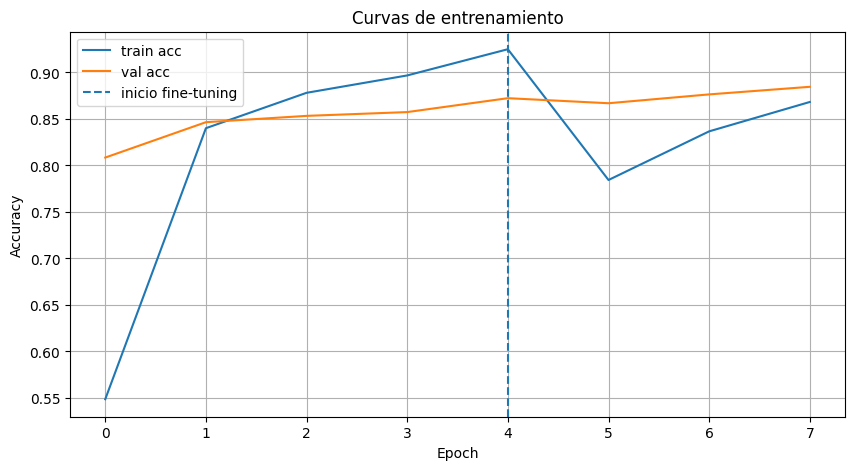

In [8]:
acc = history_1.history["accuracy"] + history_2.history["accuracy"]
val_acc = history_1.history["val_accuracy"] + history_2.history["val_accuracy"]

plt.figure(figsize=(10,5))
plt.plot(acc, label="train acc")
plt.plot(val_acc, label="val acc")
plt.axvline(x=len(history_1.history["accuracy"])-1, linestyle="--", label="inicio fine-tuning")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Curvas de entrenamiento")
plt.legend()
plt.grid(True)
plt.show()

In [9]:
loss, acc = model.evaluate(test_ds, verbose=0)
print(f"✅ Accuracy final en test: {acc:.4f}")

# Comparación con objetivos
print(f"\nObjetivo fase 1: ≥0.80 → {history_1.history['val_accuracy'][-1]:.4f}")
print(f"Objetivo fase 2: ≥0.85 → {acc:.4f}")

✅ Accuracy final en test: 0.8845

Objetivo fase 1: ≥0.80 → 0.8723
Objetivo fase 2: ≥0.85 → 0.8845


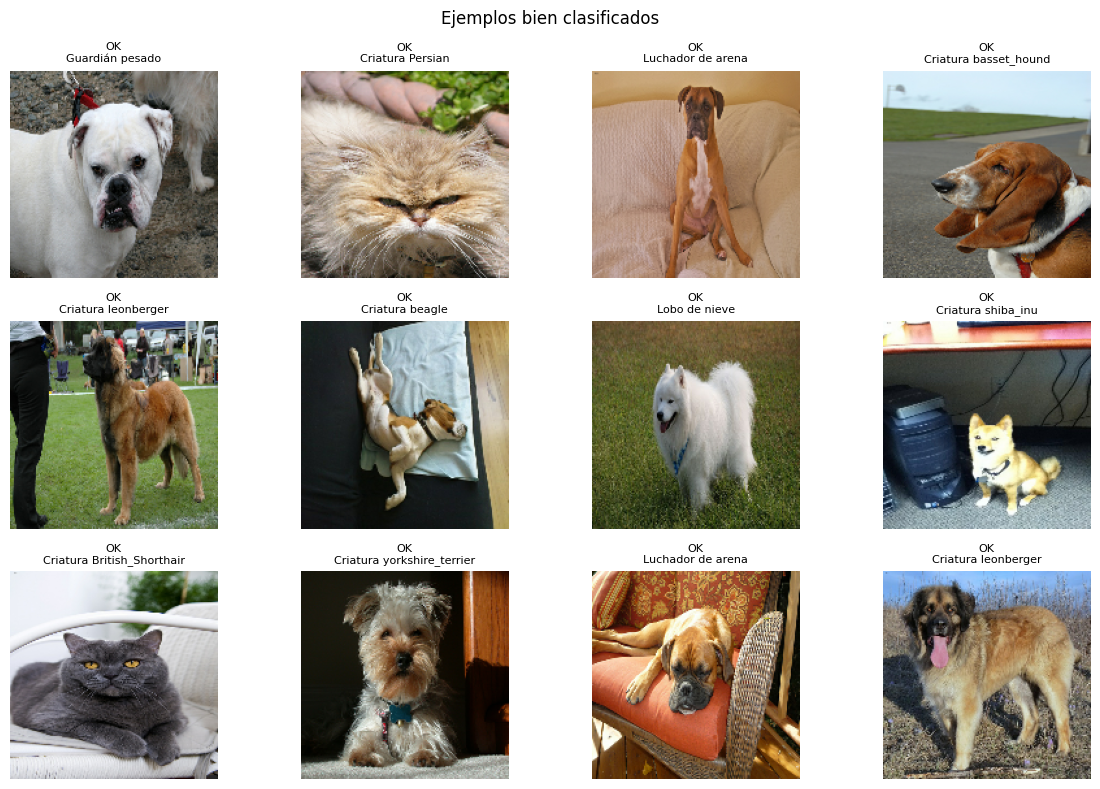

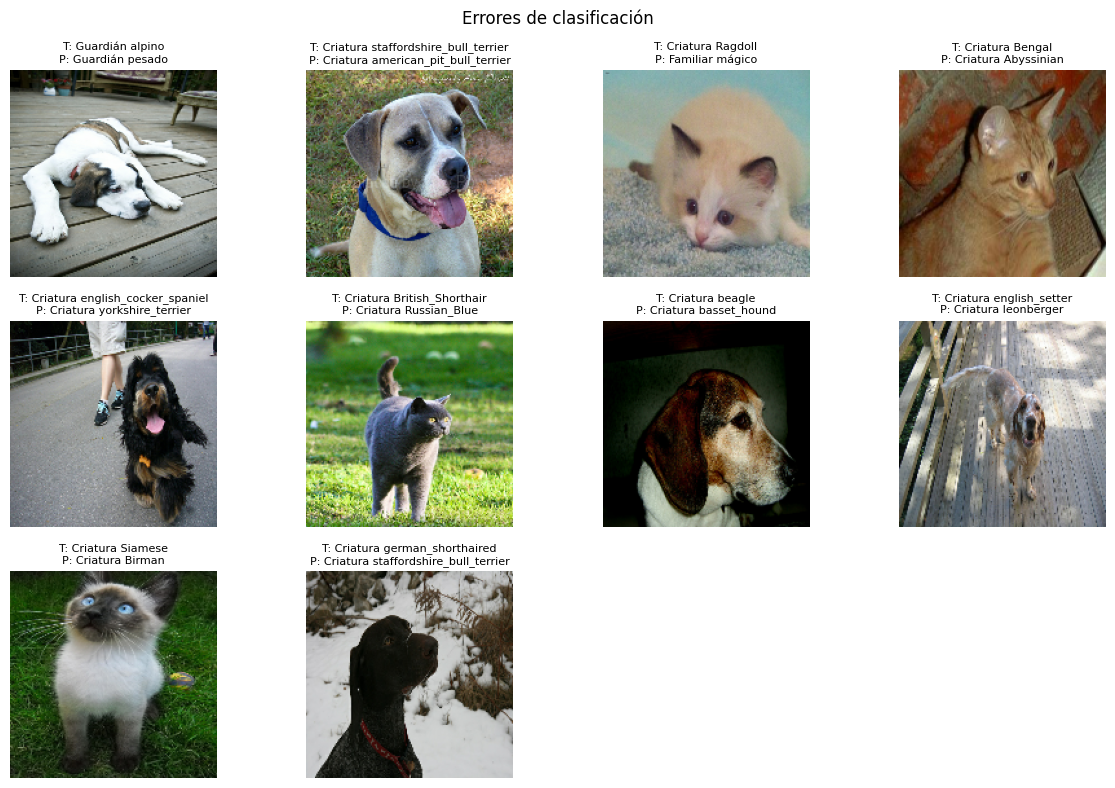

In [10]:
# Recolectamos muestras de test
sample_images = []
sample_labels = []
for images, labels in test_ds.take(3):
    sample_images.append(images)
    sample_labels.append(labels)

sample_images = tf.concat(sample_images, axis=0)
sample_labels = tf.concat(sample_labels, axis=0)

preds = model.predict(sample_images, verbose=0)
pred_classes = np.argmax(preds, axis=1)

correct = np.where(pred_classes == sample_labels.numpy())[0]
wrong = np.where(pred_classes != sample_labels.numpy())[0]

# Mostrar aciertos
plt.figure(figsize=(12,8))
for i, idx in enumerate(correct[:12]):
    plt.subplot(3,4,i+1)
    img = (sample_images[idx].numpy() + 1.0) / 2.0   # Invertir preprocesado
    plt.imshow(np.clip(img, 0, 1))
    plt.title(f"OK\n{rpg_name(label_names[int(pred_classes[idx])])}", fontsize=8)
    plt.axis("off")
plt.suptitle("Ejemplos bien clasificados")
plt.tight_layout()
plt.show()

# Mostrar errores
plt.figure(figsize=(12,8))
for i, idx in enumerate(wrong[:12]):
    plt.subplot(3,4,i+1)
    img = (sample_images[idx].numpy() + 1.0) / 2.0
    plt.imshow(np.clip(img, 0, 1))
    t = rpg_name(label_names[int(sample_labels[idx])])
    p = rpg_name(label_names[int(pred_classes[idx])])
    plt.title(f"T: {t}\nP: {p}", fontsize=8)
    plt.axis("off")
plt.suptitle("Errores de clasificación")
plt.tight_layout()
plt.show()

<Figure size 1200x1000 with 0 Axes>

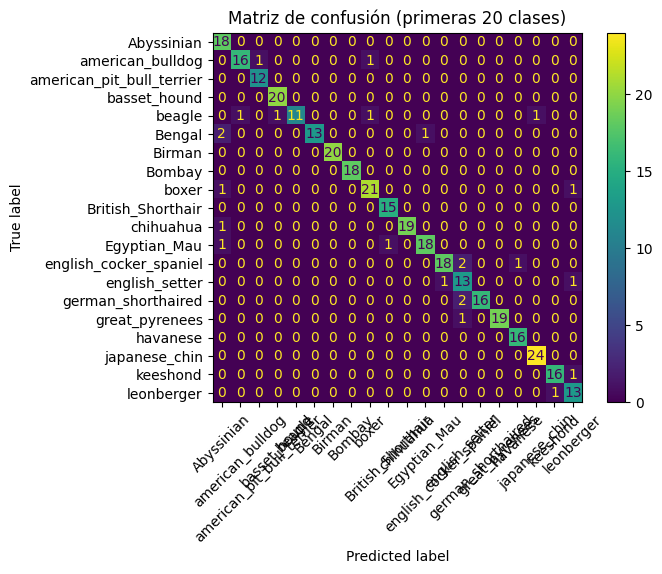

In [11]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

all_preds = []
all_true = []

for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    all_preds.append(np.argmax(preds, axis=1))
    all_true.append(labels.numpy())

all_preds = np.concatenate(all_preds)
all_true = np.concatenate(all_true)

# Limitamos a 20 clases para visualización más limpia
top_classes = list(range(20))  # mostramos solo las primeras 20
cm = confusion_matrix(all_true, all_preds, labels=top_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[label_names[i] for i in top_classes])
plt.figure(figsize=(12,10))
disp.plot(xticks_rotation=45)
plt.title("Matriz de confusión (primeras 20 clases)")
plt.show()

In [12]:
model.save("semana3_pro_equipoXX_transfer_learning.keras")
print("Modelo guardado correctamente.")

Modelo guardado correctamente.


# **Reflexión final**

**¿Por qué esta técnica es más realista que entrenar una CNN grande desde cero?**                                                                              Porque entrenar una CNN desde cero requiere millones de imágenes etiquetadas y semanas de entrenamiento para aprender patrones básicos (bordes, texturas, formas).Transfer learning reutiliza una red que ya ha aprendido características generales con enormes cantidades de datos, y solo la ajustas a tu problema con pocos ejemplos. Así se obtienen resultados buenos con recursos limitados.

**¿Qué diferencia observaste entre feature extraction y fine-tuning?**           
Feature extraction consiste en congelar la base preentrenada y entrenar solo la cabeza, lo que da una buena precisión rápidamente. Fine‑tuning descongela parte de la base y ajusta con un learning rate bajo, logrando una mejora adicional de unos pocos puntos al adaptar mejor las características al dominio específico.

**¿Qué errores comete tu modelo y por qué?**                                      
Confunde razas visualmente similares y falla en poses o fondos atípicos porque el dataset no tiene suficiente variedad para esas clases.

**¿Qué adaptarías para trabajar con sprites o criaturas 2D?**                    
Usaria un modelo preentrenado en dibujos 2D o entrenaria desde cero, ImageNet no sirve porque aprende texturas realistas. Reduciría el tamaño de entrada a 64×64, añadiría rotaciones de 0°, 90°, 180, cambios de color y escalados que deformen ligeramente la forma, porque en los juegos los personajes pueden aparecer en diferentes orientaciones.

**¿Qué limitaciones tendría este modelo si lo aplicas a sprites, enemigos o criaturas de un videojuego real?**                                       
El modelo está entrenado con fotos reales, por lo que se confunde con los colores planos y bordes definidos de los sprites, no reconoce rotaciones bruscas ni cambios de color porque solo se usaron pequeñas rotaciones en el entrenamiento, y además el tamaño de entrada y la normalización están pensados para imágenes fotográficas, no para arte 2D.